# GM Counter

1.  Study the characteristics and determine the Operating voltage.
2.  Inverse Square Law: Gamma Rays
3.  Efficiency of a GM Detector (For Gamma Source & Beta Source)
4.  Study the Nuclear Counting Statistics

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import pandas as pd
from scipy.optimize import curve_fit

## Study the characteristics and determine the Operating voltage.

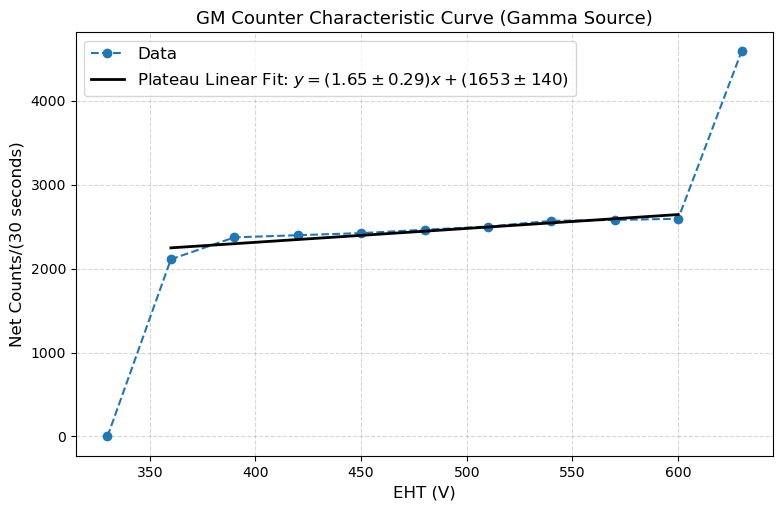

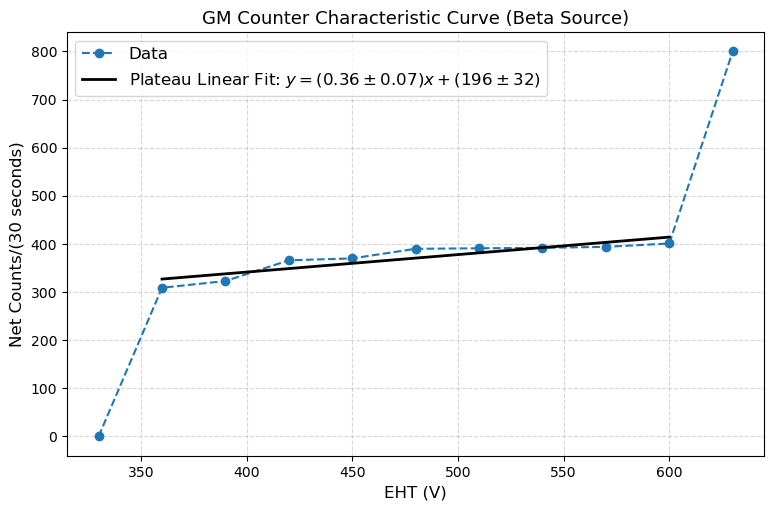

In [67]:
EHT = np.linspace(330,630,11)
Count_G = np.array([0,2147,2413,2439,2460,2507,2545,2619,2625,2638,4646])
Count_B = np.array([0,338,352,394,406,422,424,430,428,430,872])
Back_G = np.array([0,35,40,40,36,43,43,49,44,43,57])
Back_B = np.array([0,29,29,28,36,32,33,38,34,29,72])

NCount_G = Count_G - Back_G
NCount_B = Count_B - Back_B

plateau_indices = np.arange(1,10)   #select plateau region (EHT 360V to 600V)
EHT_p = EHT[plateau_indices]
Counts_p = NCount_G[plateau_indices]
p, cov = np.polyfit(EHT_p, Counts_p, 1, cov=True)
slope, intercept = p
slope_err = np.sqrt(cov[0,0])
intercept_err = np.sqrt(cov[1,1])
fit_line = slope * EHT_p + intercept
plt.figure(figsize=(9,5.5))
plt.plot(EHT, NCount_G, 'o',linestyle='--', label='Data')
fit_label = (rf'Plateau Linear Fit: $y = ({slope:.2f} \pm {slope_err:.2f})x + '
             rf'({intercept:.0f} \pm {intercept_err:.0f})$')
plt.plot(EHT_p, fit_line, linestyle='-', color='black', linewidth=2, label=fit_label)
plt.xlabel('EHT (V)', fontsize=12)
plt.ylabel('Net Counts/(30 seconds)', fontsize=12)
plt.title('GM Counter Characteristic Curve (Gamma Source)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=12)
plt.show()


plateau_indices = np.arange(1,10)   #select plateau region (EHT 360V to 600V)
EHT_p = EHT[plateau_indices]
Counts_p = NCount_B[plateau_indices]
p, cov = np.polyfit(EHT_p, Counts_p, 1, cov=True)
slope, intercept = p
slope_err = np.sqrt(cov[0,0])
intercept_err = np.sqrt(cov[1,1])
fit_line = slope * EHT_p + intercept
plt.figure(figsize=(9,5.5))
plt.plot(EHT, NCount_B, 'o',linestyle='--', label='Data')
fit_label = (rf'Plateau Linear Fit: $y = ({slope:.2f} \pm {slope_err:.2f})x + '
             rf'({intercept:.0f} \pm {intercept_err:.0f})$')
plt.plot(EHT_p, fit_line, linestyle='-', color='black', linewidth=2, label=fit_label)
plt.xlabel('EHT (V)', fontsize=12)
plt.ylabel('Net Counts/(30 seconds)', fontsize=12)
plt.title('GM Counter Characteristic Curve (Beta Source)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, fontsize=12)
plt.show()

## Inverse Square Law: Gamma Rays


R*d^2: [314.1292     495.6987     628.1408     724.8325     751.8168
 828.42503333 825.91786667 873.9738     835.61333333 825.3168
 861.0672    ]


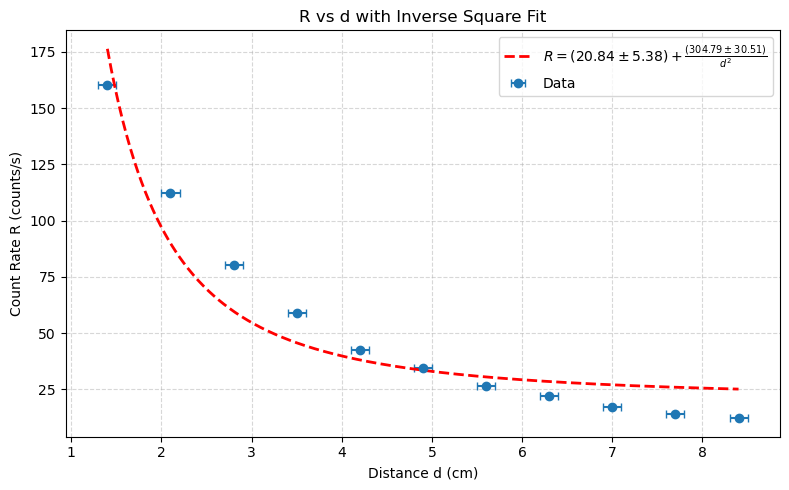

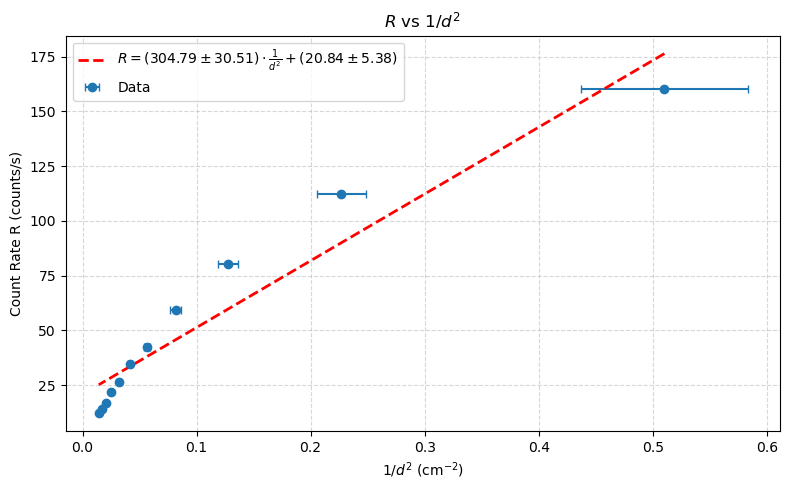

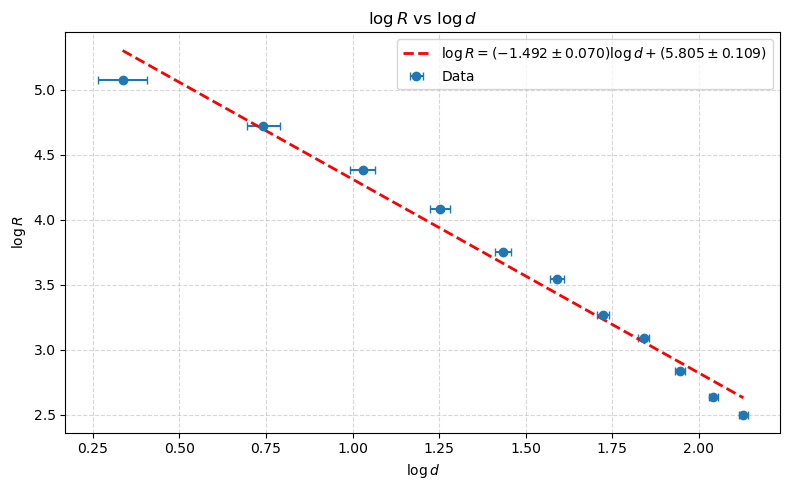

[5102.  2267.6 1275.5  816.3  566.9  416.5  318.9  252.   204.1  168.7
  141.7]


In [68]:
d = np.array([1.4,2.1,2.8,3.5,4.2,4.9,5.6,6.3,7.0,7.7,8.4])
N_i = np.array([9680,6808,4871,3614,2621,2134,1644,1385,1087,899,796])  
Back = 63.8/60
N_i = N_i/60
N_i = N_i - Back
R = N_i
C = R*d**2
print("R*d^2:", C)
d_err = np.full_like(d, 0.1)  # ±0.1 cm
# ------------------ 1. R vs d ------------------
x1 = 1 / d**2
p1, cov1 = np.polyfit(x1, R, 1, cov=True)
B, A = p1
B_err, A_err = np.sqrt(np.diag(cov1))
d_smooth = np.linspace(min(d), max(d), 500)
R_fit = A + B / d_smooth**2
plt.figure(figsize=(8,5))
plt.errorbar(d, R, xerr=d_err,
             fmt='o', capsize=3, label='Data')
label1 = rf'$R = ({A:.2f} \pm {A_err:.2f}) + \frac{{({B:.2f} \pm {B_err:.2f})}}{{d^2}}$'
plt.plot(d_smooth, R_fit, '--', linewidth=2,color='red', label=label1)
plt.xlabel('Distance d (cm)')
plt.ylabel('Count Rate R (counts/s)')
plt.title('R vs d with Inverse Square Fit')
plt.grid(alpha=0.5, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

# ------------------ 2. R vs 1/d^2 ------------------
x2 = 1 / d**2

# Propagate error: x = 1/d^2 → dx = (2/d^3)*dd
x_err = (2 / d**3) * d_err
p2, cov2 = np.polyfit(x2, R, 1, cov=True)
m, c = p2
m_err, c_err = np.sqrt(np.diag(cov2))
fit2 = m * x2 + c
plt.figure(figsize=(8,5))
plt.errorbar(x2, R, xerr=x_err,
             fmt='o', capsize=3, label='Data')
label2 = rf'$R = ({m:.2f} \pm {m_err:.2f}) \cdot \frac{{1}}{{d^2}} + ({c:.2f} \pm {c_err:.2f})$'
plt.plot(x2, fit2, '--', linewidth=2, color='red', label=label2)
plt.xlabel(r'$1/d^2$ (cm$^{-2}$)')
plt.ylabel('Count Rate R (counts/s)')
plt.title(r'$R$ vs $1/d^2$')
plt.grid(alpha=0.5, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()


# ------------------ 3. log(R) vs log(d) ------------------
log_d = np.log(d)
# Propagate error: σ(log d) = σd / d
log_d_err = d_err / d
log_R = np.log(R)
p3, cov3 = np.polyfit(log_d, log_R, 1, cov=True)
slope, intercept = p3
slope_err, intercept_err = np.sqrt(np.diag(cov3))
fit3 = slope * log_d + intercept
plt.figure(figsize=(8,5))
plt.errorbar(log_d, log_R, xerr=log_d_err,
             fmt='o', capsize=3, label='Data')
label3 = rf'$\log R = ({slope:.3f} \pm {slope_err:.3f}) \log d + ({intercept:.3f} \pm {intercept_err:.3f})$'
plt.plot(log_d, fit3, '--', linewidth=2, color='red', label=label3)
plt.xlabel(r'$\log d$')
plt.ylabel(r'$\log R$')
plt.title(r'$\log R$ vs $\log d$')
plt.grid(alpha=0.5, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

print(np.round((1/d**2)*10000, 1))

## Estimation of Efficiency for the GM Detector

In [69]:
A0 = 10
A1 = 79
def Activity(A0, t_half, t):
    return A0 * np.exp(-t * np.log(2)/t_half)

print("Activity of Beta Source after 10 years:", Activity(A0, 3.78, 10))
print("Activity of Gamma Source after 10 years:", Activity(A1, 30, 10))

def R(A, d, D):
    return (A*(d**2))/(16*D**2)

Rb = R(1.60e3, 3, 2)
print("R for Beta Source:", Rb)
Rg = R(62.7e3, 3, 10)
print("R for Gamma Source:", Rg)

def Efficiency(R, N):
    return (N*100/R)

Ng = (np.mean([675,633,595]) - np.mean([183,164,137]))/100
Nb = (np.mean([1437,1354,1382]) - np.mean([183,164,137]))/100

print("Efficiency for Beta Source:", Efficiency(Rb, Nb))
print("Efficiency for Gamma Source:", Efficiency(Rg, Ng))

Activity of Beta Source after 10 years: 1.59817506370654
Activity of Gamma Source after 10 years: 62.702341552743874
R for Beta Source: 225.0
R for Gamma Source: 352.6875
Efficiency for Beta Source: 5.465185185185185
Efficiency for Gamma Source: 1.3411306042884992


## Study of Nuclear Counting Statistics

    No.  Background Counts  Average Value N  Ni - N  (Ni - N)^2
0     1                 78            70.56    7.44       55.37
1     2                 60            70.56  -10.56      111.49
2     3                 75            70.56    4.44       19.72
3     4                 72            70.56    1.44        2.08
4     5                 56            70.56  -14.56      211.96
5     6                 61            70.56   -9.56       91.37
6     7                 83            70.56   12.44      154.78
7     8                 71            70.56    0.44        0.19
8     9                 71            70.56    0.44        0.19
9    10                 64            70.56   -6.56       43.02
10   11                 55            70.56  -15.56      242.08
11   12                 71            70.56    0.44        0.19
12   13                 85            70.56   14.44      208.55
13   14                 75            70.56    4.44       19.72
14   15                 75            70

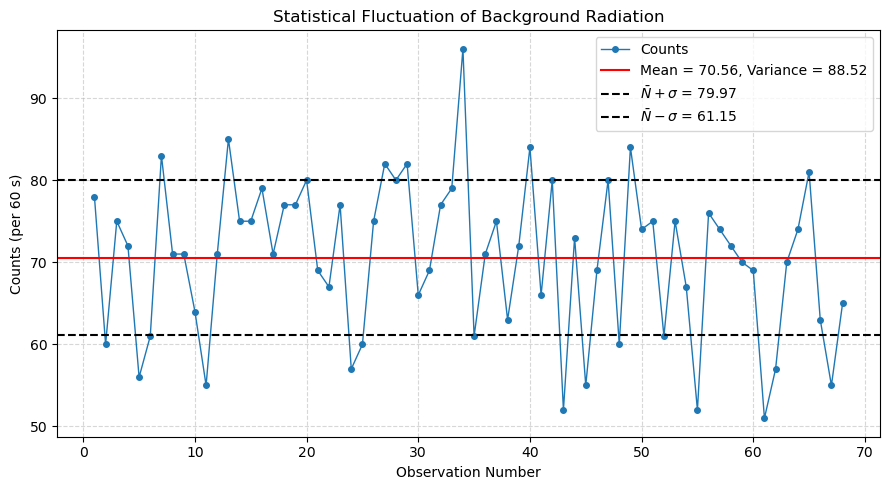

In [70]:
# For Background data
D = pd.read_csv(r'Nuclear Counting Statistics - Background data.csv')
mean_N = D['Background Counts'].mean()
D['Average Value N'] = mean_N
D['Ni - N'] = D['Background Counts'] - D['Average Value N']
D['(Ni - N)^2'] = (D['Ni - N']) ** 2
# Round only for display
D['Average Value N'] = D['Average Value N'].round(2)
D['Ni - N'] = D['Ni - N'].round(2)
D['(Ni - N)^2'] = D['(Ni - N)^2'].round(2)
print(D)

N = D['Background Counts'].values
n = len(N)
variance = np.sum((N - mean_N)**2) / (n - 1)
sigma = np.sqrt(variance)

print(f"Mean of Background Counts: {mean_N:.3f}")
print(f"Variance of Background Counts: {variance:.3f}")
print(f"Standard Deviation: {sigma:.3f}")

within_sigma = np.sum((N >= mean_N - sigma) & (N <= mean_N + sigma))
print(f"Points within ±σ: {within_sigma}/{n}")

# ------------------ GRAPH ------------------
x = np.arange(1, n+1)
plt.figure(figsize=(9,5))
plt.plot(x, N, 'o-', linewidth=1, markersize=4, label='Counts')
plt.axhline(mean_N, linewidth=1.5,
            label=rf'Mean = {mean_N:.2f}, Variance = {variance:.2f}', color='red')

plt.axhline(mean_N + sigma, linestyle='--',
            label=rf'$\bar{{N}} + \sigma$ = {mean_N + sigma:.2f}', color='black')

plt.axhline(mean_N - sigma, linestyle='--',
            label=rf'$\bar{{N}} - \sigma$ = {mean_N - sigma:.2f}', color='black')
plt.xlabel('Observation Number')
plt.ylabel('Counts (per 60 s)')
plt.title('Statistical Fluctuation of Background Radiation')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

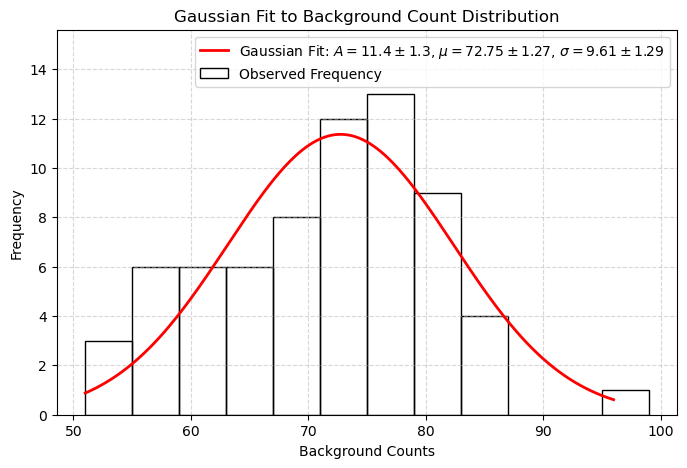

A = 11.361 ± 1.301
Mean (μ) = 72.749 ± 1.269
Sigma (σ) = 9.609 ± 1.295


In [71]:
N = D['Background Counts'].values
n = len(N)

bin_width = 4  
bins = np.arange(min(N), max(N) + bin_width, bin_width)

freq, bin_edges = np.histogram(N, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

p0 = [max(freq), np.mean(N), np.std(N)]
popt, pcov = curve_fit(gaussian, bin_centers, freq, p0=p0)
A, mu, sigma = popt
A_err, mu_err, sigma_err = np.sqrt(np.diag(pcov))

x_fit = np.linspace(min(N), max(N), 300)
y_fit = gaussian(x_fit, *popt)

plt.figure(figsize=(8,5))
plt.bar(bin_centers, freq, width=bin_width*1,
        edgecolor='black', fill=False, label='Observed Frequency')
label = (rf'Gaussian Fit: '
         rf'$A = {A:.1f} \pm {A_err:.1f}$, '
         rf'$\mu = {mu:.2f} \pm {mu_err:.2f}$, '
         rf'$\sigma = {sigma:.2f} \pm {sigma_err:.2f}$')
plt.plot(x_fit, y_fit, linestyle='-',color='red', linewidth=2, label=label)
plt.xlabel('Background Counts')
plt.ylabel('Frequency')
plt.title('Gaussian Fit to Background Count Distribution')
plt.ylim(0, max(freq)*1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

print(f"A = {A:.3f} ± {A_err:.3f}")
print(f"Mean (μ) = {mu:.3f} ± {mu_err:.3f}")
print(f"Sigma (σ) = {sigma:.3f} ± {sigma_err:.3f}")

Sigma: 26.474
Mean of Counts: 734.55
Variance of Counts: 700.8563768115941
    S.no.  Counts  N (avg.)  Ni - N  (Ni - N)^2  (Ni - N)/sigma  \
0       1     770    734.55   35.45     1256.65        1.339065   
1       2     673    734.55  -61.55     3788.49       -2.324950   
2       3     751    734.55   16.45      270.58        0.621372   
3       4     723    734.55  -11.55      133.42       -0.436282   
4       5     716    734.55  -18.55      344.13       -0.700696   
5       6     756    734.55   21.45      460.07        0.810238   
6       7     759    734.55   24.45      597.77        0.923558   
7       8     728    734.55   -6.55       42.91       -0.247415   
8       9     724    734.55  -10.55      111.32       -0.398509   
9      10     749    734.55   14.45      208.78        0.545825   
10     11     691    734.55  -43.55     1896.67       -1.645029   
11     12     698    734.55  -36.55     1335.96       -1.380616   
12     13     715    734.55  -19.55      382.23       

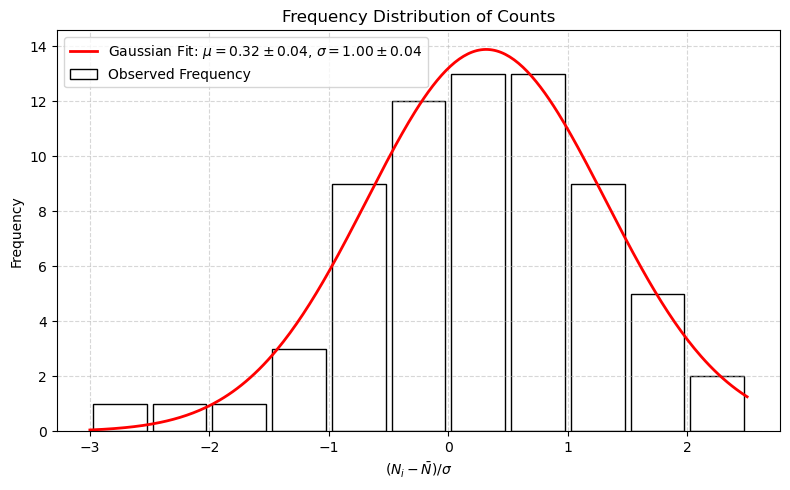

mu = 0.316 ± 0.042
sigma = 0.997 ± 0.043


In [77]:
#For Counts data
D1 = pd.read_csv(r'Nuclear Counting Statistics -  Counts.csv')
mean_N = D1['Counts'].mean()
D1['N (avg.)'] = mean_N
D1['Ni - N'] = D1['Counts'] - D1['N (avg.)']
D1['(Ni - N)^2'] = (D1['Ni - N']) ** 2
D1['N (avg.)'] = D1['N (avg.)'].round(2)
D1['Ni - N'] = D1['Ni - N'].round(2)
D1['(Ni - N)^2'] = D1['(Ni - N)^2'].round(2)

var = D1['(Ni - N)^2'].mean()
mean_N = D1['N (avg.)'].iloc[0]
sigma = np.sqrt(var)
print(f"Sigma: {sigma:.3f}")

def rd(x): #Round of the nearest 0.5 
    return np.round(x * 2) / 2
    
D1['(Ni - N)/sigma'] = (D1['Ni - N']) / sigma
print("Mean of Counts:", mean_N)
print("Variance of Counts:", var)
D1['(Ni - N)/sigma (rounded)'] = rd(D1['(Ni - N)/sigma'])
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(D1)


Zr = D1['(Ni - N)/sigma (rounded)'].values

bin_width = 0.5   

bins = np.arange(min(Zr), max(Zr) + bin_width, bin_width)

freq, bin_edges = np.histogram(Zr, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

p0 = [max(freq), 0, 1]
popt, pcov = curve_fit(gaussian, bin_centers, freq, p0=p0)
A, mu, sigma_fit = popt
A_err, mu_err, sigma_err = np.sqrt(np.diag(pcov))
x_fit = np.linspace(min(Zr), max(Zr), 300)
y_fit = gaussian(x_fit, *popt)

plt.figure(figsize=(8,5))
plt.bar(bin_centers, freq, width=bin_width*0.9,
        edgecolor='black', fill=False,
        label='Observed Frequency')

label = (rf'Gaussian Fit: '
         rf'$\mu = {mu:.2f} \pm {mu_err:.2f}$, '
         rf'$\sigma = {sigma_fit:.2f} \pm {sigma_err:.2f}$')

plt.plot(x_fit, y_fit, linestyle='-',color='red', linewidth=2, label=label)
plt.xlabel(r'$(N_i - \bar{N})/\sigma$')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of Counts')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f"mu = {mu:.3f} ± {mu_err:.3f}")
print(f"sigma = {sigma_fit:.3f} ± {sigma_err:.3f}")